<a href="https://colab.research.google.com/github/ShauryaPrakashVerma/Python_for_AI/blob/main/MLT_3_ID3_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Wap to demonstrate the working of decision tree based ID3 Algorithm . use an approrpriate dataset for building the decision tree and apply this knowledge to classify the new sample.
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import math


In [ ]:
df = pd.read_csv('play_tennis.csv')
df.head()

,day,outlook,temp,humidity,wind,play
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes


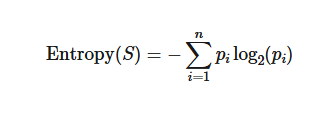

In [ ]:
def calculate_entropy(data, target_column):
    print(data)
    total_rows = len(data)
    target_values = data[target_column].unique()
    print(target_values)

    entropy = 0
    for value in target_values:
        value_count = len(data[data[target_column] == value])
        print(value_count)
        proportion = value_count / total_rows
        print("{}/{}".format(value_count , total_rows))
        entropy -= proportion * math.log2(proportion)
    return entropy

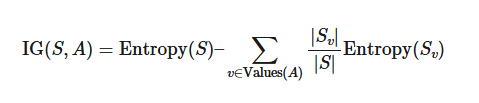

In [ ]:
def information_gain(data, attribute, target_column):
  unique_values = data[attribute].unique()
  weighted_entropy = 0
  print(unique_values)

In [ ]:
calculate_entropy(df, "outlook")
print("----------------------------------------------------------------------------------------------------------------------------------")
information_gain(df, "outlook", "humidity")


    day   outlook  temp humidity    wind play
0    D1     Sunny   Hot     High    Weak   No
1    D2     Sunny   Hot     High  Strong   No
2    D3  Overcast   Hot     High    Weak  Yes
3    D4      Rain  Mild     High    Weak  Yes
4    D5      Rain  Cool   Normal    Weak  Yes
5    D6      Rain  Cool   Normal  Strong   No
6    D7  Overcast  Cool   Normal  Strong  Yes
7    D8     Sunny  Mild     High    Weak   No
8    D9     Sunny  Cool   Normal    Weak  Yes
9   D10      Rain  Mild   Normal    Weak  Yes
10  D11     Sunny  Mild   Normal  Strong  Yes
11  D12  Overcast  Mild     High  Strong  Yes
12  D13  Overcast   Hot   Normal    Weak  Yes
13  D14      Rain  Mild     High  Strong   No
['Sunny' 'Overcast' 'Rain']
5
5/14
4
4/14
5
5/14
---------------------------------------------------------------------------------------
['Sunny' 'Overcast' 'Rain']


In [30]:
import pandas as pd
import numpy as np
from math import log2


In [31]:
def calculate_entropy(data):
    labels = data.iloc[:, -1].value_counts()
    total = len(data)
    entropy = -sum((count / total) * log2(count / total) for count in labels)
    return entropy

In [32]:
def calculate_information_gain(data, attribute):
    total_entropy = calculate_entropy(data)
    values = data[attribute].unique()
    weighted_entropy = 0

    for value in values:
        subset = data[data[attribute] == value]
        weighted_entropy += (len(subset) / len(data)) * calculate_entropy(subset)

    return total_entropy - weighted_entropy

In [33]:
def id3(data, features):
    if len(data.iloc[:, -1].unique()) == 1:
        return data.iloc[0, -1]

    if len(features) == 0:
        return data.iloc[:, -1].mode()[0]

    gains = {feature: calculate_information_gain(data, feature) for feature in features}
    best_feature = max(gains, key=gains.get)

    tree = {best_feature: {}}
    for value in data[best_feature].unique():
        subset = data[data[best_feature] == value]
        remaining_features = [feat for feat in features if feat != best_feature]
        tree[best_feature][value] = id3(subset, remaining_features)

    return tree

In [34]:
pip install graphviz

In [35]:
from graphviz import Digraph

def visualize_tree(tree, dot=None, parent_name=None, edge_label=None, node_counter=None):
    if dot is None:
        dot = Digraph(comment='Decision Tree')
        node_counter = [0]
    node_id = str(node_counter[0])
    node_counter[0] += 1

    if isinstance(tree, dict):
        feature = list(tree.keys())[0]
        dot.node(node_id, feature, shape='box')

        if parent_name is not None:
            dot.edge(parent_name, node_id, label=edge_label)

        for value, subtree in tree[feature].items():
            visualize_tree(subtree, dot, node_id, str(value), node_counter)
    else:
        dot.node(node_id, str(tree), shape='ellipse')

        if parent_name is not None:
            dot.edge(parent_name, node_id, label=edge_label)

    return dot
visualize_tree(tree).view()

'Digraph.gv.pdf'

In [44]:
data = pd.DataFrame({
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rainy', 'Rainy'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool'],
    'Humidity': ['High', 'High', 'High', 'Normal', 'Normal'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak'],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes']
})

features = list(data.columns[:-1])
tree = id3(data, features)
print(tree)
dot_graph = visualize_tree(tree)
dot_graph.render('decision_tree', format='png', view=False, cleanup=True)
print("Shaurya Prakash Verma")
print("2300971530120")

{'Outlook': {'Sunny': 'No', 'Overcast': 'Yes', 'Rainy': 'Yes'}}
Shaurya Prakash Verma
2300971530120


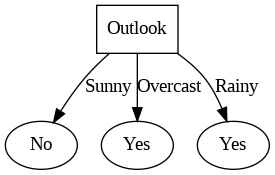

In [38]:
from IPython.display import Image
Image('decision_tree.png')